In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from scipy import stats

In [2]:
df = pd.read_csv("../data/raw/Video_Games_Sales_as_at_22_Dec_2016.csv")
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [4]:
df.describe(include="all")

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
count,16717,16719,16450.000000,16717,16665,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,10015,7590.000000,10096,9950
unique,11562,31,NaN,12,581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,NaN,1696,8
top,Need for Speed: Most Wanted,PS2,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tbd,NaN,Ubisoft,E
freq,12,2161,NaN,3370,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2425,NaN,204,3991
mean,NaN,NaN,2006.487356,NaN,NaN,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,NaN,162.229908,NaN,NaN
std,NaN,NaN,5.878995,NaN,NaN,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,NaN,561.282326,NaN,NaN
min,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,NaN,4.000000,NaN,NaN
25%,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,NaN,10.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,NaN,24.000000,NaN,NaN
75%,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,NaN,81.000000,NaN,NaN


In [5]:
X = df.drop(columns=["Global_Sales"])
y = df["Global_Sales"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(13375, 15)
(3344, 15)
(13375,)
(3344,)


In [8]:
X_train.isnull().sum()

Name                  1
Platform              0
Year_of_Release     211
Genre                 1
Publisher            42
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Critic_Score       6868
Critic_Count       6868
User_Score         5372
User_Count         7310
Developer          5310
Rating             5429
dtype: int64

In [9]:
X_train.groupby("Year_of_Release")[["Critic_Score", "Critic_Count"]].mean()

,Critic_Score,Critic_Count
Year_of_Release,,
1980.0,NaN,NaN
1981.0,NaN,NaN
1982.0,NaN,NaN
1983.0,NaN,NaN
1984.0,NaN,NaN
1985.0,59.000000,9.000000
1986.0,NaN,NaN
1987.0,NaN,NaN
1988.0,64.000000,75.000000


Gran cantidad de nulos en las features relacionadas con las criticas entre los años 1980 y 1995.
Al tener un gran numero de registros decidimos eliminar los missing values. Pensamos que no es una buena idea aplicar el imputer por la cantidad de missings y tampoco queremos eliminar las features, ya que opinamos que pueden aportar información valiosa

In [10]:
X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_test = X_test.dropna()
y_test = y_test[X_test.index]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5470, 15)
(1355, 15)
(5470,)
(1355,)


### EDA

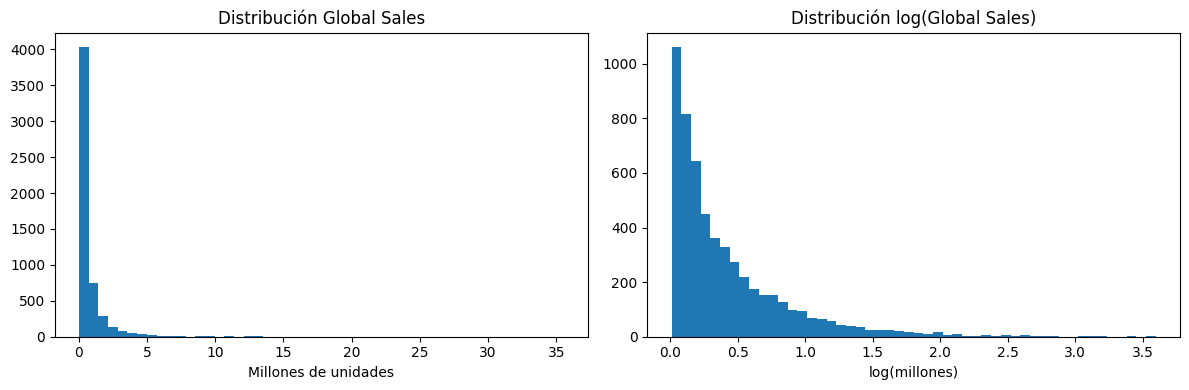

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50)
axes[0].set_title('Distribución Global Sales')
axes[0].set_xlabel('Millones de unidades')

axes[1].hist(np.log1p(y_train), bins=50)
axes[1].set_title('Distribución log(Global Sales)')
axes[1].set_xlabel('log(millones)')

plt.tight_layout()
plt.show()

In [12]:
y_train.sort_values(ascending=False)

2        35.52
6        29.80
7        28.92
11       23.21
13       22.70
         ...  
16421     0.01
16164     0.01
16320     0.01
16263     0.01
16355     0.01
Name: Global_Sales, Length: 5470, dtype: float64

In [13]:
y_train.describe()

count    5470.000000
mean        0.757525
std         1.624007
min         0.010000
25%         0.110000
50%         0.290000
75%         0.767500
max        35.520000
Name: Global_Sales, dtype: float64

### Distribución de Global_Sales
El target presenta una fuerte asimetría positiva (cola hacia la derecha).
La mayoría de juegos venden menos de 1M de unidades, mientras que unos pocos superan las 5M. Conviene hacer el logaritmo para acercar los valores

In [14]:
train_set = X_train.copy()
train_set["Global_Sales"] = y_train

In [15]:
genre_sales = round(train_set.groupby("Genre")["Global_Sales"].mean().sort_values(ascending=False), 3)
genre_sales

Genre
Misc            0.946
Shooter         0.935
Platform        0.898
Racing          0.844
Sports          0.766
Action          0.759
Role-Playing    0.687
Fighting        0.681
Simulation      0.678
Puzzle          0.669
Adventure       0.335
Strategy        0.246
Name: Global_Sales, dtype: float64

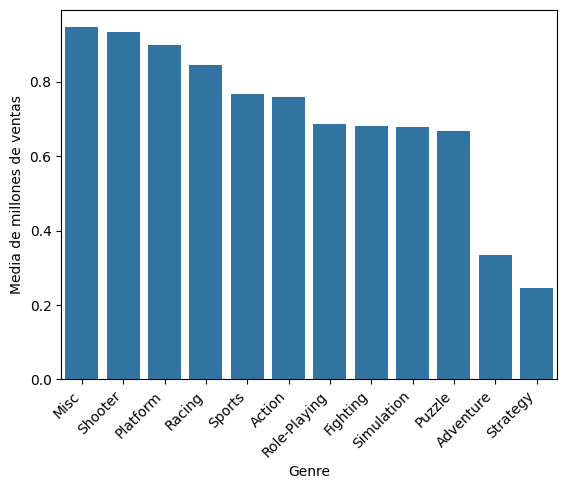

In [16]:
sns.barplot(genre_sales)
plt.ylabel("Media de millones de ventas")
plt.xticks(rotation= 45, ha= "right");

In [17]:
platform_sales = round(train_set.groupby("Platform")["Global_Sales"].mean().sort_values(ascending=False), 3)
platform_sales

Platform
PS      1.551
Wii     1.079
PS4     1.058
PS3     1.004
X360    0.974
3DS     0.903
DS      0.850
XOne    0.838
PS2     0.823
WiiU    0.672
GBA     0.544
PSP     0.492
GC      0.479
XB      0.381
DC      0.380
PSV     0.277
PC      0.252
Name: Global_Sales, dtype: float64

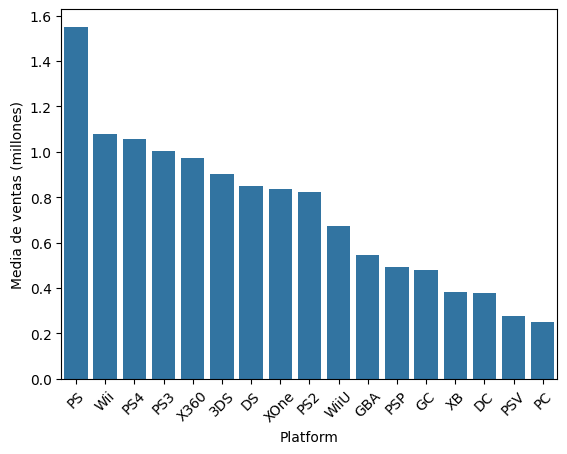

In [18]:
sns.barplot(platform_sales)
plt.ylabel("Media de ventas (millones)")
plt.xticks(rotation= 45, ha= "center");

In [19]:
sales_year = train_set.groupby("Year_of_Release")["Global_Sales"].sum()

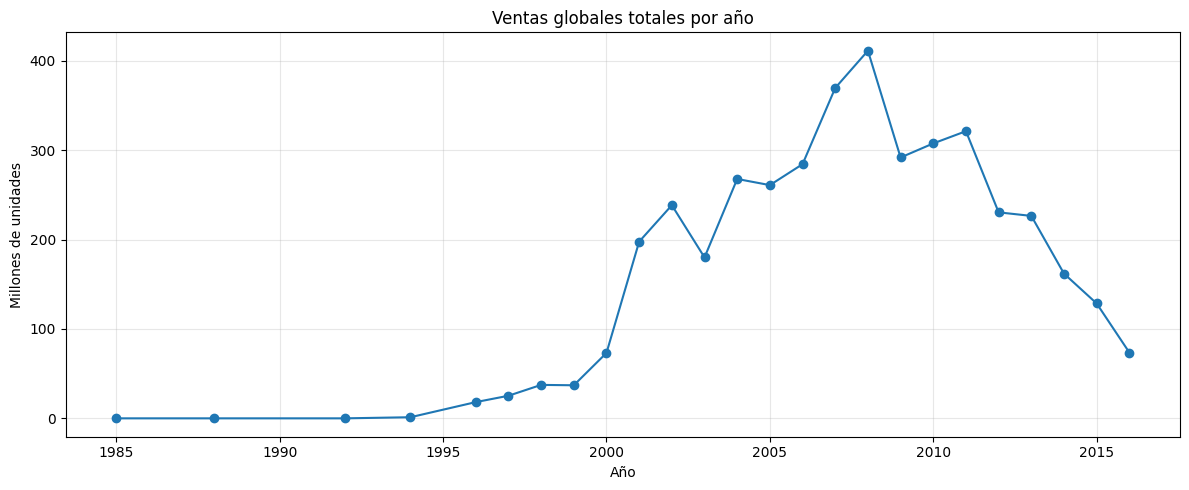

In [20]:
plt.figure(figsize=(12, 5))
sales_year.plot(kind='line', marker='o')
plt.title('Ventas globales totales por año')
plt.ylabel('Millones de unidades')
plt.xlabel('Año')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Observamos una subida en el numero de copias vendidas en el año 2000 llegando a un pico de más de 400 millones de ventas en 2008 que luego decrece por debajo de las 100 millones.

In [21]:
sales_publisher = round(train_set.groupby("Publisher")["Global_Sales"].mean().sort_values(ascending=False).head(15), 3)

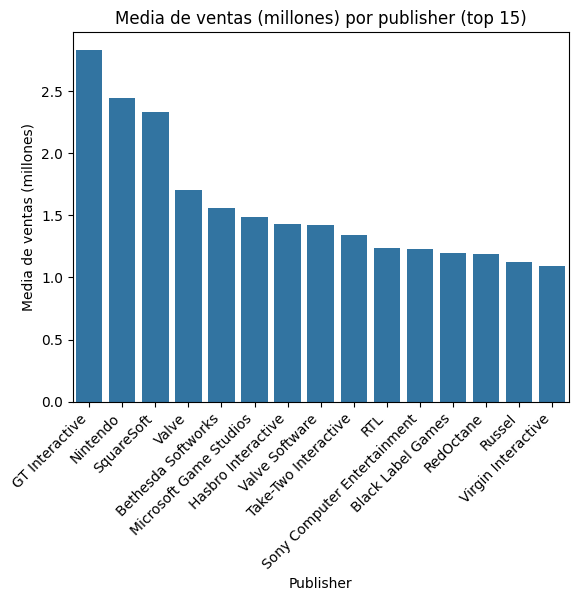

In [22]:
sns.barplot(sales_publisher)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Media de ventas (millones)")
plt.title("Media de ventas (millones) por publisher (top 15)");

Aquí observamos los 20 publishers con mayor media de ventas

In [23]:
sales_region = train_set[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].mean()

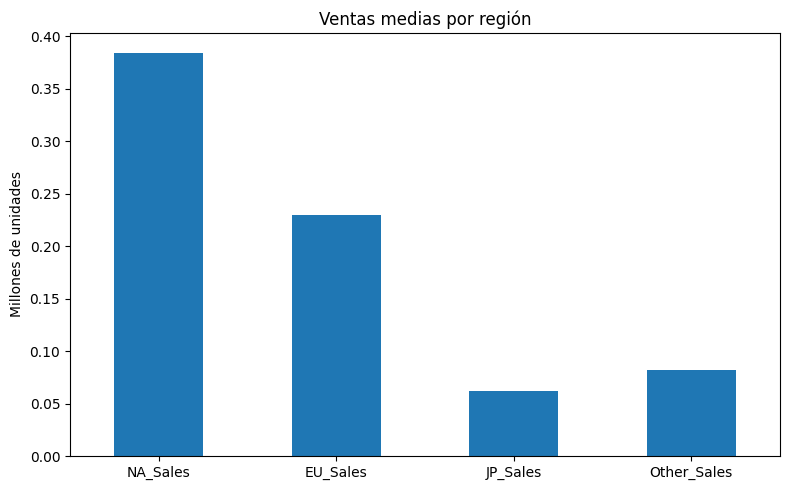

In [24]:
plt.figure(figsize=(8, 5))
sales_region.plot(kind='bar')
plt.title('Ventas medias por región')
plt.ylabel('Millones de unidades')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
train_set.dtypes

Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Critic_Score       float64
Critic_Count       float64
User_Score          object
User_Count         float64
Developer           object
Rating              object
Global_Sales       float64
dtype: object

In [26]:
train_set["User_Score"] = train_set["User_Score"].astype("float")

<Axes: >

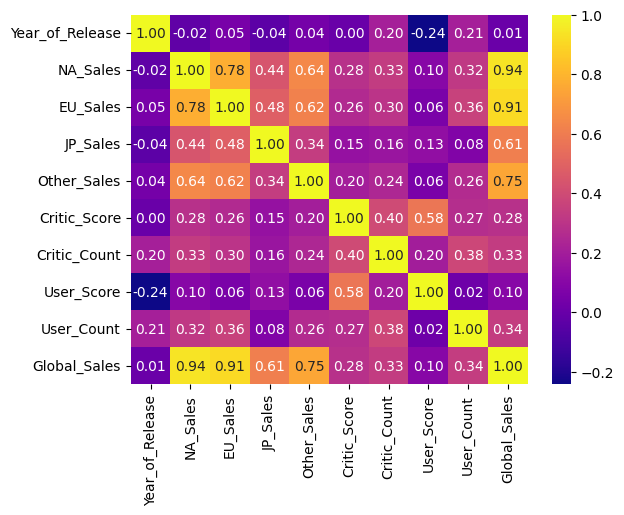

In [27]:
sns.heatmap(train_set.corr(numeric_only=True), annot=True, cmap="plasma", fmt=".2f")

Se observa fuerte colinealidad entre las ventas por region y ventas globales, como es evidente. Al margen de eso, no se aprecian columnas numericas que tengan una buena relacion lineal con nuestro target

<Axes: xlabel='Critic_Score', ylabel='Global_Sales'>

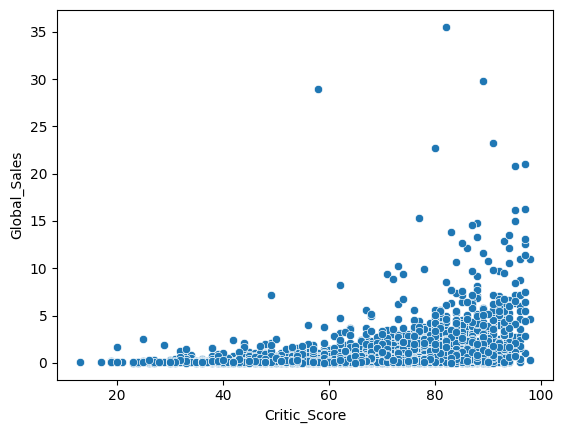

In [28]:
sns.scatterplot(train_set, x="Critic_Score", y="Global_Sales")

Observamos cierta relacion entre el critic_score y global_sales

<Axes: xlabel='Critic_Count', ylabel='Global_Sales'>

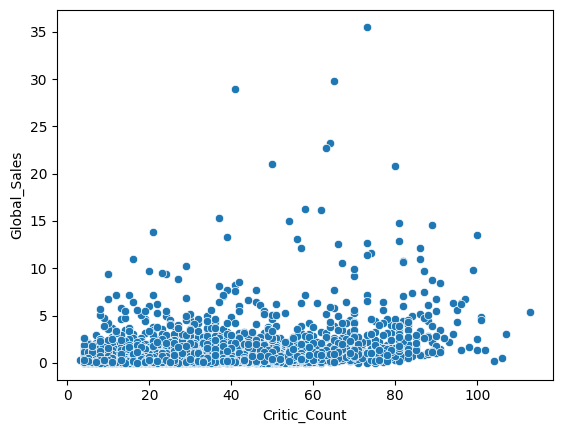

In [29]:
sns.scatterplot(train_set, x="Critic_Count", y="Global_Sales")

<Axes: xlabel='User_Count', ylabel='Global_Sales'>

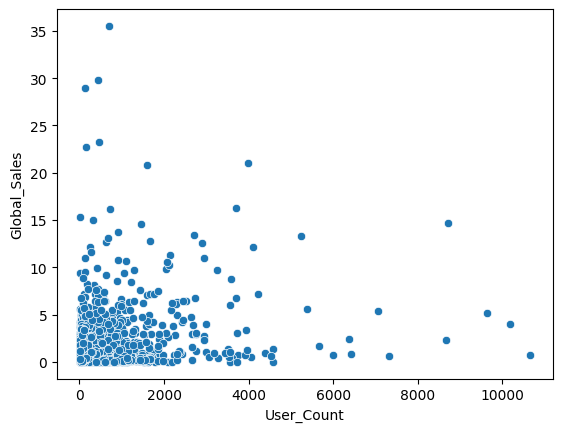

In [30]:
sns.scatterplot(train_set, x="User_Count", y="Global_Sales")

In [31]:
train_set['User_Score'] = pd.to_numeric(train_set['User_Score'])

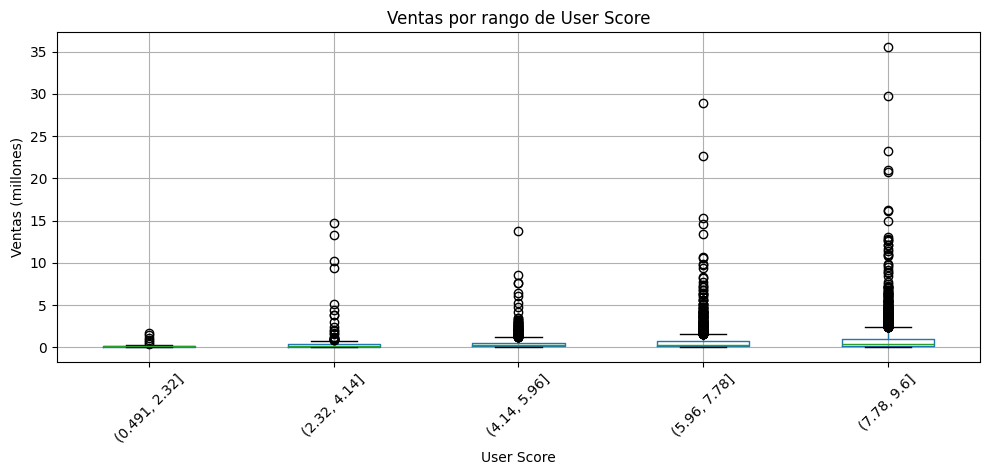

In [32]:
train_set['User_Score_bin'] = pd.cut(train_set['User_Score'], bins=5)
train_set.boxplot(column='Global_Sales', by='User_Score_bin', figsize=(10, 5))
plt.title('Ventas por rango de User Score')
plt.suptitle('')
plt.xlabel('User Score')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Engineering

In [33]:
from scipy.stats import shapiro, skew
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [34]:
print("Shapiro p-value:", shapiro(train_set["Global_Sales"]).pvalue)
print("Skew:", skew(train_set["Global_Sales"]))

print("Shapiro p-value:", shapiro(np.log1p(train_set["Global_Sales"])).pvalue)
print("Skew:", skew(np.log1p(train_set["Global_Sales"])))

Shapiro p-value: 2.3753272676209496e-86
Skew: 8.304999986579597
Shapiro p-value: 4.15306260820962e-65
Skew: 2.116815086843047


c:\Users\paspe\Desktop\DATA_SCIENCE\ML-project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5470.
  res = hypotest_fun_out(*samples, **kwds)


Antes de hacer modificaciones, guardamos el train y test separado en sus respectivas carpetas

In [35]:
X_train.to_csv("../data/train/X_train_no_mod.csv")
y_train.to_csv("../data/train/y_train_no_mod.csv", index=False)

X_test.to_csv("../data/test/X_test_no_mod.csv")
y_test.to_csv("../data/test/y_test_no_mod.csv", index=False)

Para comenzar, aplicamos el logaritmo a nuestro target tanto en train como en test para mejorar la distribucion.

In [36]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Lo guardamos en data/processed

In [37]:
y_train_log.to_csv("../data/processed/y_train_log.csv", index=False)
y_test_log.to_csv("../data/processed/y_test_log.csv", index=False)

<Axes: xlabel='Global_Sales', ylabel='Count'>

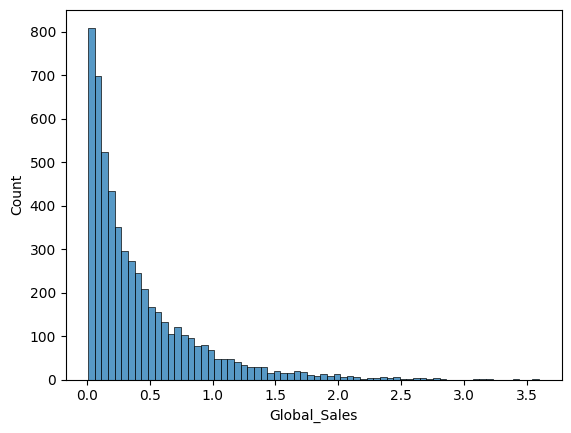

In [38]:
sns.histplot(y_train_log)

Categorizamos el año de lanzamiento de videojuego en decadas. Lo aplicamos tanto en train como en test

In [39]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

In [40]:
def clasificar_decada(year):
    if year < 1990:
        return "pre-90s"
    elif year < 2000:
        return "90s"
    elif year < 2010:
        return "2000s"
    else:
        return "2010s"

X_train_processed["Decade"] = X_train_processed["Year_of_Release"].apply(clasificar_decada)
X_test_processed["Decade"] = X_test_processed["Year_of_Release"].apply(clasificar_decada)

In [41]:
X_train_processed["Platform"].value_counts()

Platform
PS2     905
X360    705
PS3     612
PC      522
XB      448
Wii     389
DS      358
PSP     330
GC      274
GBA     193
PS4     190
XOne    128
3DS     121
PS      111
PSV      96
WiiU     77
DC       11
Name: count, dtype: int64

In [42]:
X_train_processed["Publisher"].value_counts()

Publisher
Electronic Arts                752
Activision                     400
Ubisoft                        400
Sony Computer Entertainment    255
THQ                            238
                              ... 
Telegames                        1
Popcorn Arcade                   1
Encore                           1
2D Boy                           1
Conspiracy Entertainment         1
Name: count, Length: 239, dtype: int64

In [43]:
X_train_processed["Genre"].value_counts()

Genre
Action          1293
Sports           781
Shooter          695
Role-Playing     567
Racing           474
Platform         323
Misc             318
Fighting         293
Simulation       233
Strategy         208
Adventure        193
Puzzle            92
Name: count, dtype: int64

Al tener un numero alto de publishers unicos, decidimos hacer agrupación antes de aplicar onehotencoder. Agrupamos por bins según la cantidad de juegos que han publicado en una nueva feature y aplicamos los cambios a train y test para unificar criterios.

Por otro lado, en genero y plataforma decidimos no aplicar este metodo, ya que perderíamos información valiosa.

In [44]:
bins = [0, 200, 500, 1000]
labels = ["Publisher 1", "Publisher 2", "Publisher 3"]
publisher_counts = X_train_processed["Publisher"].value_counts()

publisher_bins = pd.cut(publisher_counts, bins=bins, labels=labels)
X_train_processed["Cat_Publisher"] = X_train_processed["Publisher"].map(publisher_bins)
X_test_processed["Cat_Publisher"] = X_test_processed["Publisher"].map(publisher_bins)

X_train_processed["Cat_Publisher"].value_counts()

Cat_Publisher
Publisher 1    2737
Publisher 2    1981
Publisher 3     752
Name: count, dtype: int64

In [45]:
X_train_processed

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Decade,Cat_Publisher
3307,Dragon Ball Z: Ultimate Tenkaichi,PS3,2011.0,Fighting,Namco Bandai Games,0.27,0.18,0.09,0.07,58.0,26.0,5.4,77.0,Spike,T,2010s,Publisher 1
10050,NFL Head Coach 09,X360,2008.0,Sports,Electronic Arts,0.11,0.00,0.00,0.01,67.0,14.0,8.4,28.0,EA Tiburon,E,2000s,Publisher 3
7017,Madagascar: Escape 2 Africa,PS3,2008.0,Action,Activision,0.12,0.08,0.00,0.03,58.0,13.0,6.8,4.0,Toys for Bob,E10+,2000s,Publisher 2
2519,Shin Megami Tensei: Persona 4,PS2,2008.0,Role-Playing,Atlus,0.34,0.04,0.36,0.08,90.0,47.0,8.9,634.0,Atlus Co.,M,2000s,Publisher 1
8956,Earth Defense Force 2025,X360,2013.0,Shooter,D3Publisher,0.06,0.03,0.05,0.01,68.0,25.0,8.1,63.0,Sandlot,M,2010s,Publisher 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14423,Sorcery Saga: The Curse of the Great Curry God,PSV,2013.0,Role-Playing,Rising Star Games,0.00,0.00,0.03,0.00,65.0,17.0,7.3,44.0,Zerodiv,T,2010s,Publisher 1
4426,Transformers: Fall of Cybertron,X360,2012.0,Action,Activision,0.28,0.12,0.00,0.04,79.0,52.0,8.3,160.0,High Moon Studios,T,2010s,Publisher 2
11964,Grand Kingdom,PS4,2015.0,Role-Playing,Nippon Ichi Software,0.03,0.00,0.03,0.01,78.0,33.0,8.1,63.0,Spike Chunsoft,T,2010s,Publisher 1
5390,Monopoly,PS3,2008.0,Misc,Electronic Arts,0.25,0.05,0.00,0.04,54.0,4.0,6.7,13.0,Electronic Arts,E,2000s,Publisher 3


In [46]:
X_train_processed.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Score', 'Critic_Count',
       'User_Score', 'User_Count', 'Developer', 'Rating', 'Decade',
       'Cat_Publisher'],
      dtype='object')

Eliminamos las features que no aportan información al modelo. El nombre por cardinalidad alta, el año de lanzamiento y publisher porque las hemos transformado en decadas y grupos y las ventas por region por colinealidad con el target.

In [47]:
drop_cols = ["Name", "Year_of_Release", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Publisher", "Developer"]
X_train_processed = X_train_processed.drop(columns=drop_cols)
X_test_processed = X_test_processed.drop(columns=drop_cols)

X_train_processed

,Platform,Genre,Critic_Score,Critic_Count,User_Score,User_Count,Rating,Decade,Cat_Publisher
3307,PS3,Fighting,58.0,26.0,5.4,77.0,T,2010s,Publisher 1
10050,X360,Sports,67.0,14.0,8.4,28.0,E,2000s,Publisher 3
7017,PS3,Action,58.0,13.0,6.8,4.0,E10+,2000s,Publisher 2
2519,PS2,Role-Playing,90.0,47.0,8.9,634.0,M,2000s,Publisher 1
8956,X360,Shooter,68.0,25.0,8.1,63.0,M,2010s,Publisher 1
...,...,...,...,...,...,...,...,...,...
14423,PSV,Role-Playing,65.0,17.0,7.3,44.0,T,2010s,Publisher 1
4426,X360,Action,79.0,52.0,8.3,160.0,T,2010s,Publisher 2
11964,PS4,Role-Playing,78.0,33.0,8.1,63.0,T,2010s,Publisher 1
5390,PS3,Misc,54.0,4.0,6.7,13.0,E,2000s,Publisher 3


In [48]:
X_train_processed.columns

Index(['Platform', 'Genre', 'Critic_Score', 'Critic_Count', 'User_Score',
       'User_Count', 'Rating', 'Decade', 'Cat_Publisher'],
      dtype='object')

In [49]:
X_train_processed["User_Score"] = X_train_processed["User_Score"].astype("float")

In [50]:
num_cols = ["Critic_Score", "User_Score", "Critic_Count", "User_Count"]
cat_cols = ["Genre", "Platform", "Rating", "Decade", "Cat_Publisher"]

array([[<Axes: title={'center': 'Critic_Score'}>,
        <Axes: title={'center': 'User_Score'}>],
       [<Axes: title={'center': 'Critic_Count'}>,
        <Axes: title={'center': 'User_Count'}>]], dtype=object)

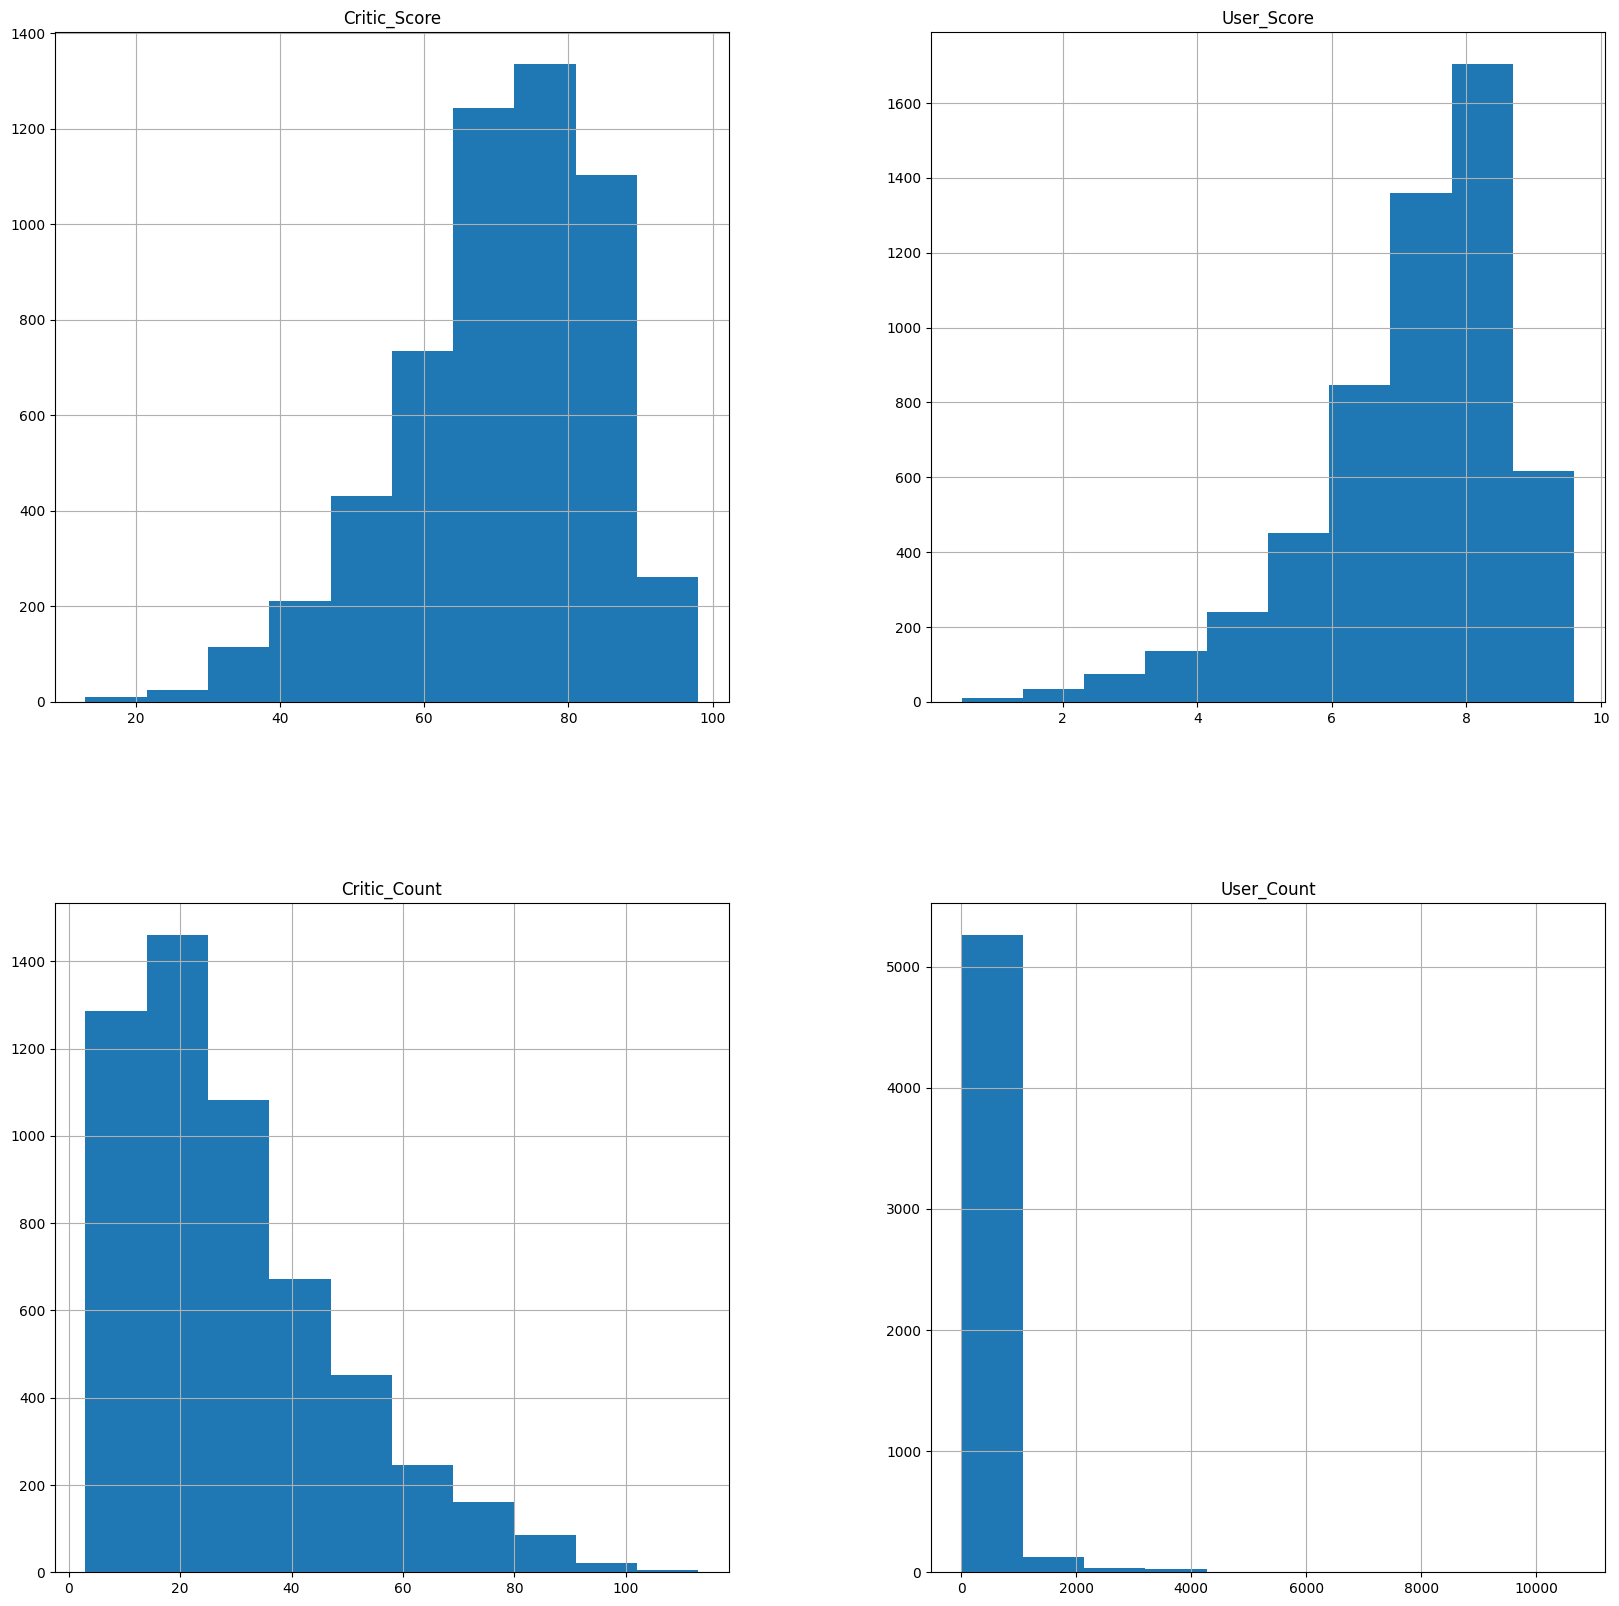

In [51]:
X_train_processed[num_cols].hist(figsize= (20, 20))

#### Modelo No Supervisado

Aplicamos K-means para añadir una feature de clusters.

En primer lugar, hacemos un escalado de las columnas numericas para después hacer un fit_transform.

Pintamos la gráfica del codo para obtener el numero de k (clusters) óptimo

In [ ]:
# X_cluster = X_train_processed[num_cols]

# scaler = StandardScaler()
# X_cluster_scaled = scaler.fit_transform(X_cluster)

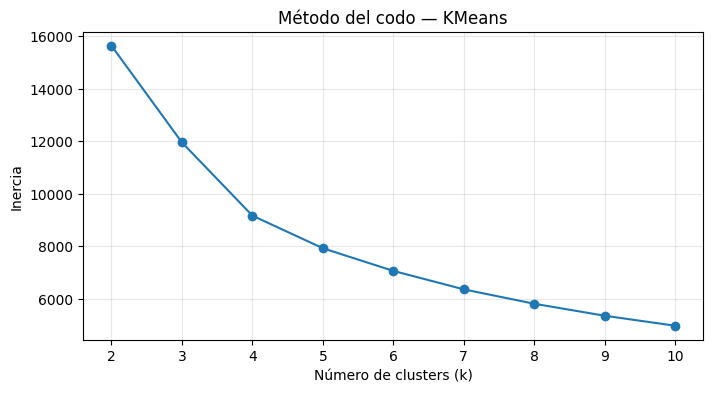

In [ ]:
# inertias = []
# k_range = range(2, 11)

# for k in k_range:
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans.fit(X_cluster_scaled)
#     inertias.append(kmeans.inertia_)

# plt.figure(figsize=(8, 4))
# plt.plot(k_range, inertias, marker='o')
# plt.title('Método del codo — KMeans')
# plt.xlabel('Número de clusters (k)')
# plt.ylabel('Inercia')
# plt.xticks(k_range)
# plt.grid(alpha=0.3)
# plt.show()

Observamos con el método del codo el número de clusters óptimo en 4

In [ ]:
# k_optimo = 4

# kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
# kmeans.fit(X_cluster_scaled)
# X_train_processed["Cluster"] = kmeans.predict(X_cluster_scaled)

Aplicamos la mismas transformaciones a X_test_processed

In [ ]:
# X_cluster_test = X_test_processed[num_cols]
# X_cluster_test_scaled = scaler.transform(X_cluster_test)
# X_test_processed["Cluster"] = kmeans.predict(X_cluster_test_scaled)

Una vez hemos creado la columna de cluster gracias al k means, procedemos al tratamiento de las columnas categoricas con el ONE HOT ENCODING

In [52]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop= "first", handle_unknown="ignore", sparse_output=False), cat_cols)
], remainder="passthrough")

X_train_processed = preprocessor.fit_transform(X_train_processed)
X_test_processed = preprocessor.transform(X_test_processed)

c:\Users\paspe\Desktop\DATA_SCIENCE\ML-project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [53]:
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace('cat__', '').replace('remainder__', '') for name in feature_names]

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

In [54]:
X_train_processed

,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,...,Rating_T,Decade_2010s,Decade_90s,Decade_pre-90s,Cat_Publisher_Publisher 2,Cat_Publisher_Publisher 3,Critic_Score,Critic_Count,User_Score,User_Count
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,58.0,26.0,5.4,77.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,67.0,14.0,8.4,28.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,58.0,13.0,6.8,4.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90.0,47.0,8.9,634.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,68.0,25.0,8.1,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5465,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,65.0,17.0,7.3,44.0
5466,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,79.0,52.0,8.3,160.0
5467,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,78.0,33.0,8.1,63.0
5468,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,54.0,4.0,6.7,13.0


In [ ]:
# X_train_processed["Cluster"].value_counts()

Cluster
0.0    2798
2.0    1306
1.0    1283
3.0      83
Name: count, dtype: int64

In [55]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5470, 40)
(1355, 40)


Guardamos el x_train_processed con y sin modelo no supervisado (_C)

In [56]:
X_train_processed.to_csv("../data/processed/X_train_processed.csv", index=False)
X_test_processed.to_csv("../data/processed/X_test_processed.csv", index=False)